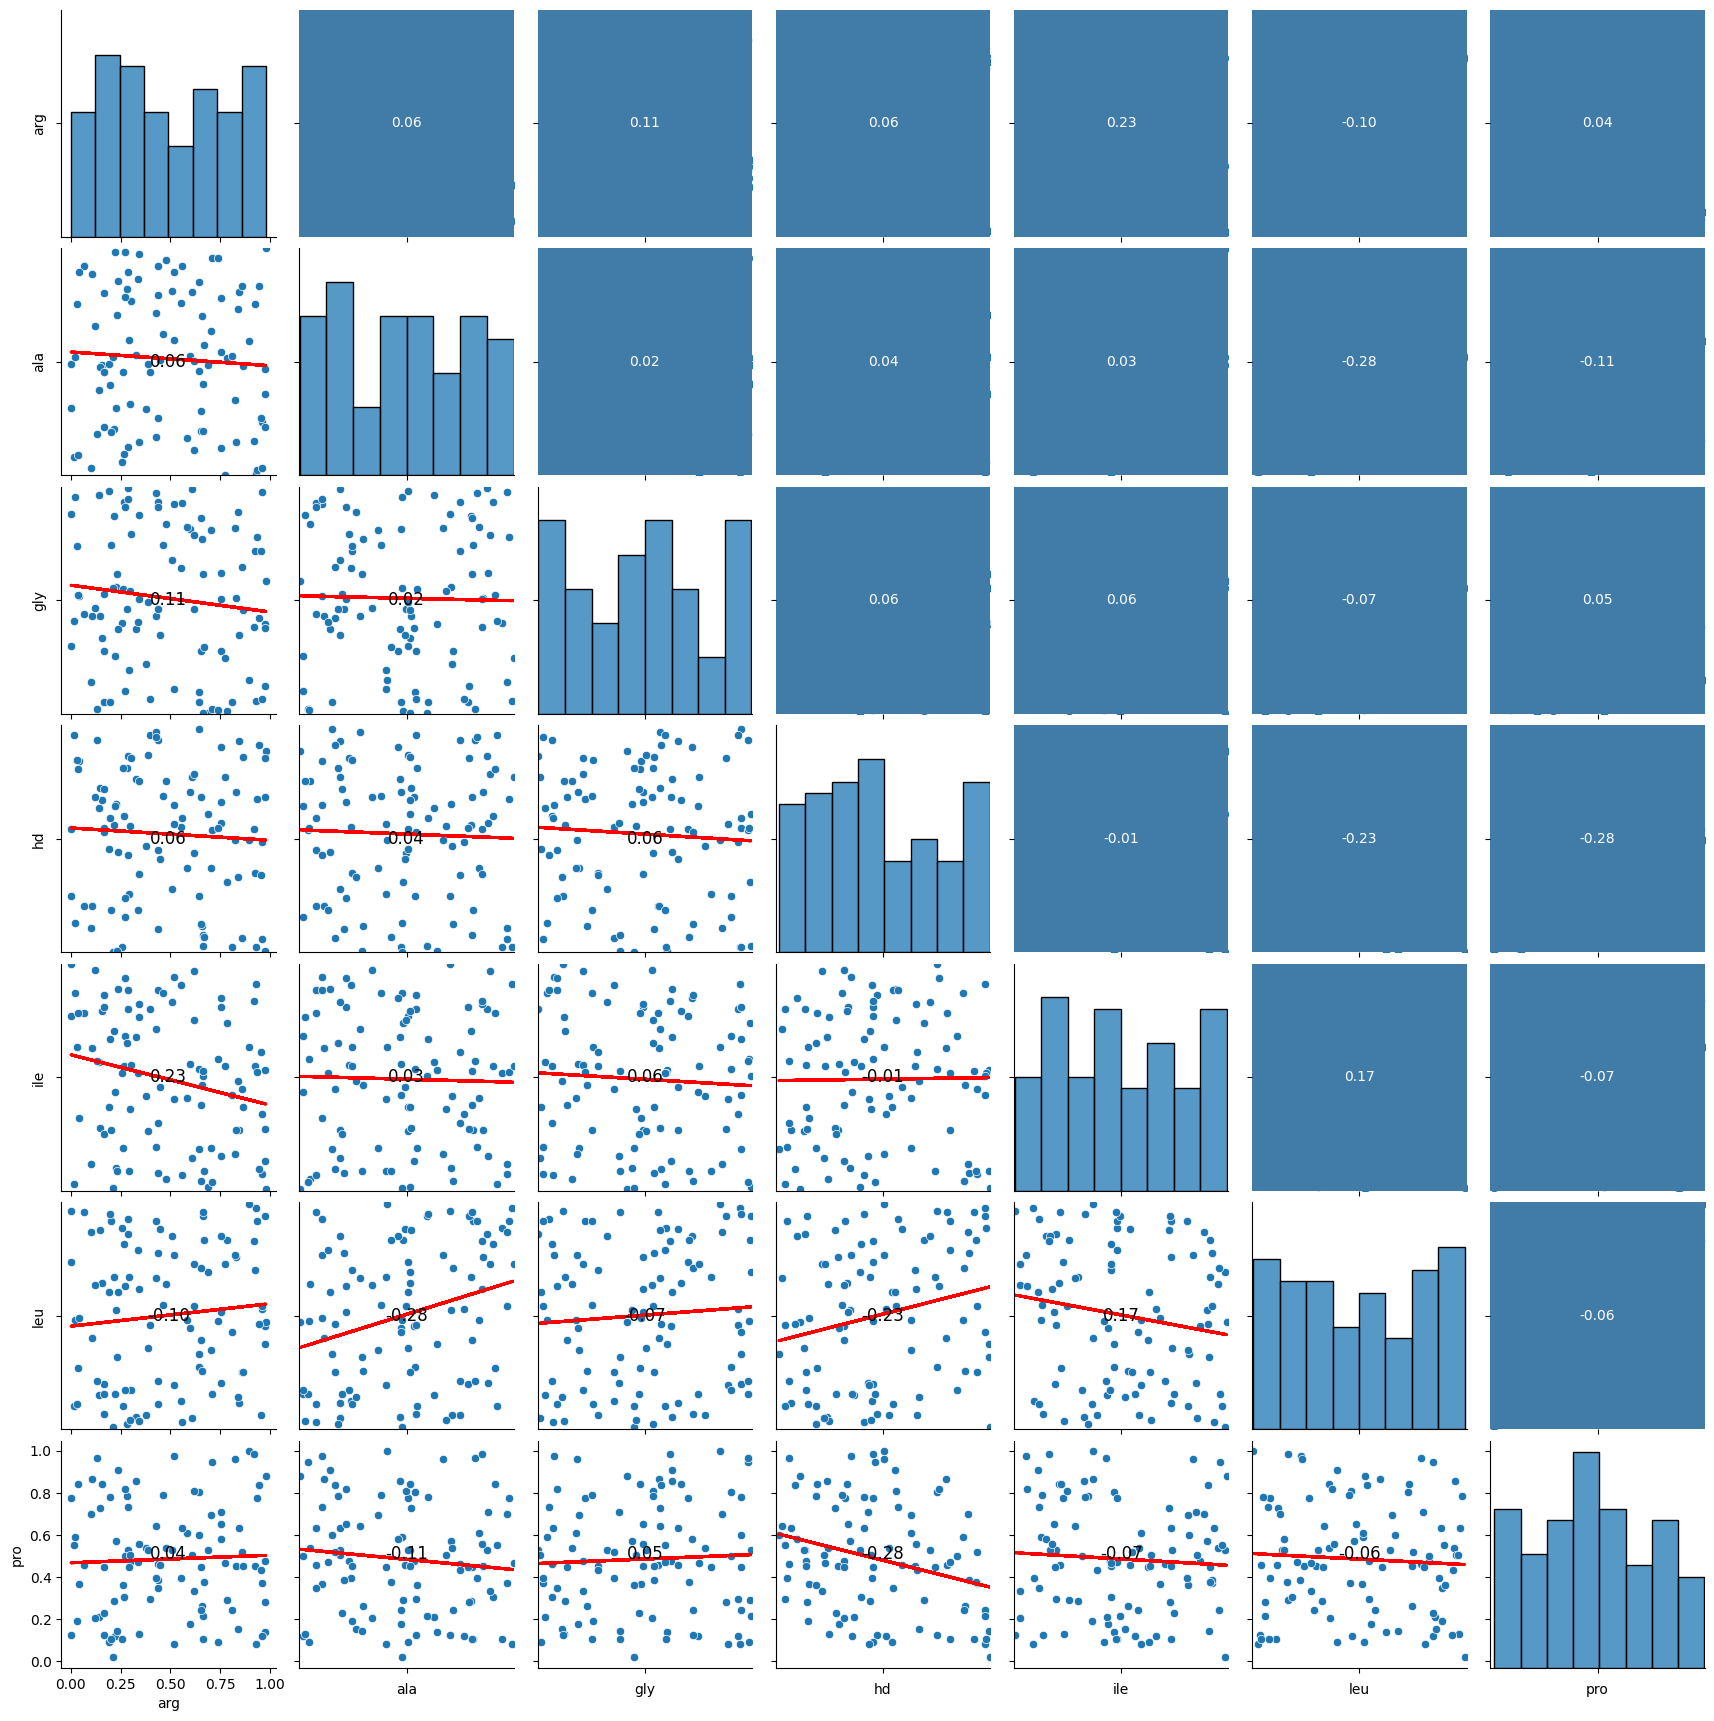

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm


# Function to calculate the correlation and annotate the matrix
def correlation_with_stars(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f"{r:.2f}", xy=(0.5, 0.5), xycoords='axes fraction',
                ha='center', va='center', fontsize=12)
    ax.annotate(f"{'***' if abs(r) > 0.7 else ''}", xy=(0.5, 0.7), xycoords='axes fraction',
                ha='center', va='center', fontsize=10, color='red')

# Function to plot OLS regression line on the scatterplots
def plot_ols(x, y, **kws):
    ax = plt.gca()
    # Add constant for the intercept in OLS
    x_ = sm.add_constant(x)
    model = sm.OLS(y, x_).fit()
    # Predict values
    pred = model.predict(x_)
    # Plot the regression line
    ax.plot(x, pred, color='red', linewidth=2)

# Function to fill the upper diagonal with heatmap colors based on correlation
def heatmap_upper(x, y, **kws):
    ax = plt.gca()
    r, _ = pearsonr(x, y)
    cmap = sns.diverging_palette(240, 10, as_cmap=True)  # Adjust palette as needed
    sns.heatmap([[r]], annot=True, fmt=".2f", cmap=cmap, cbar=False, ax=ax)
    ax.set_xticklabels([])
    ax.set_yticklabels([])


# Load your data here (replace this with your actual data loading code)
# Example with random data
df = pd.DataFrame(np.random.rand(100, 7), columns=['arg', 'ala', 'gly', 'hd', 'ile', 'leu', 'pro'])

# Create a pairplot with OLS regression line and correlation annotations
g = sns.pairplot(df)

# Add correlation annotations and OLS regression line
g.map_lower(correlation_with_stars)
g.map_lower(plot_ols)

# Add heatmap for correlation in the upper triangle
g.map_upper(heatmap_upper)

# Show the plot
plt.show()



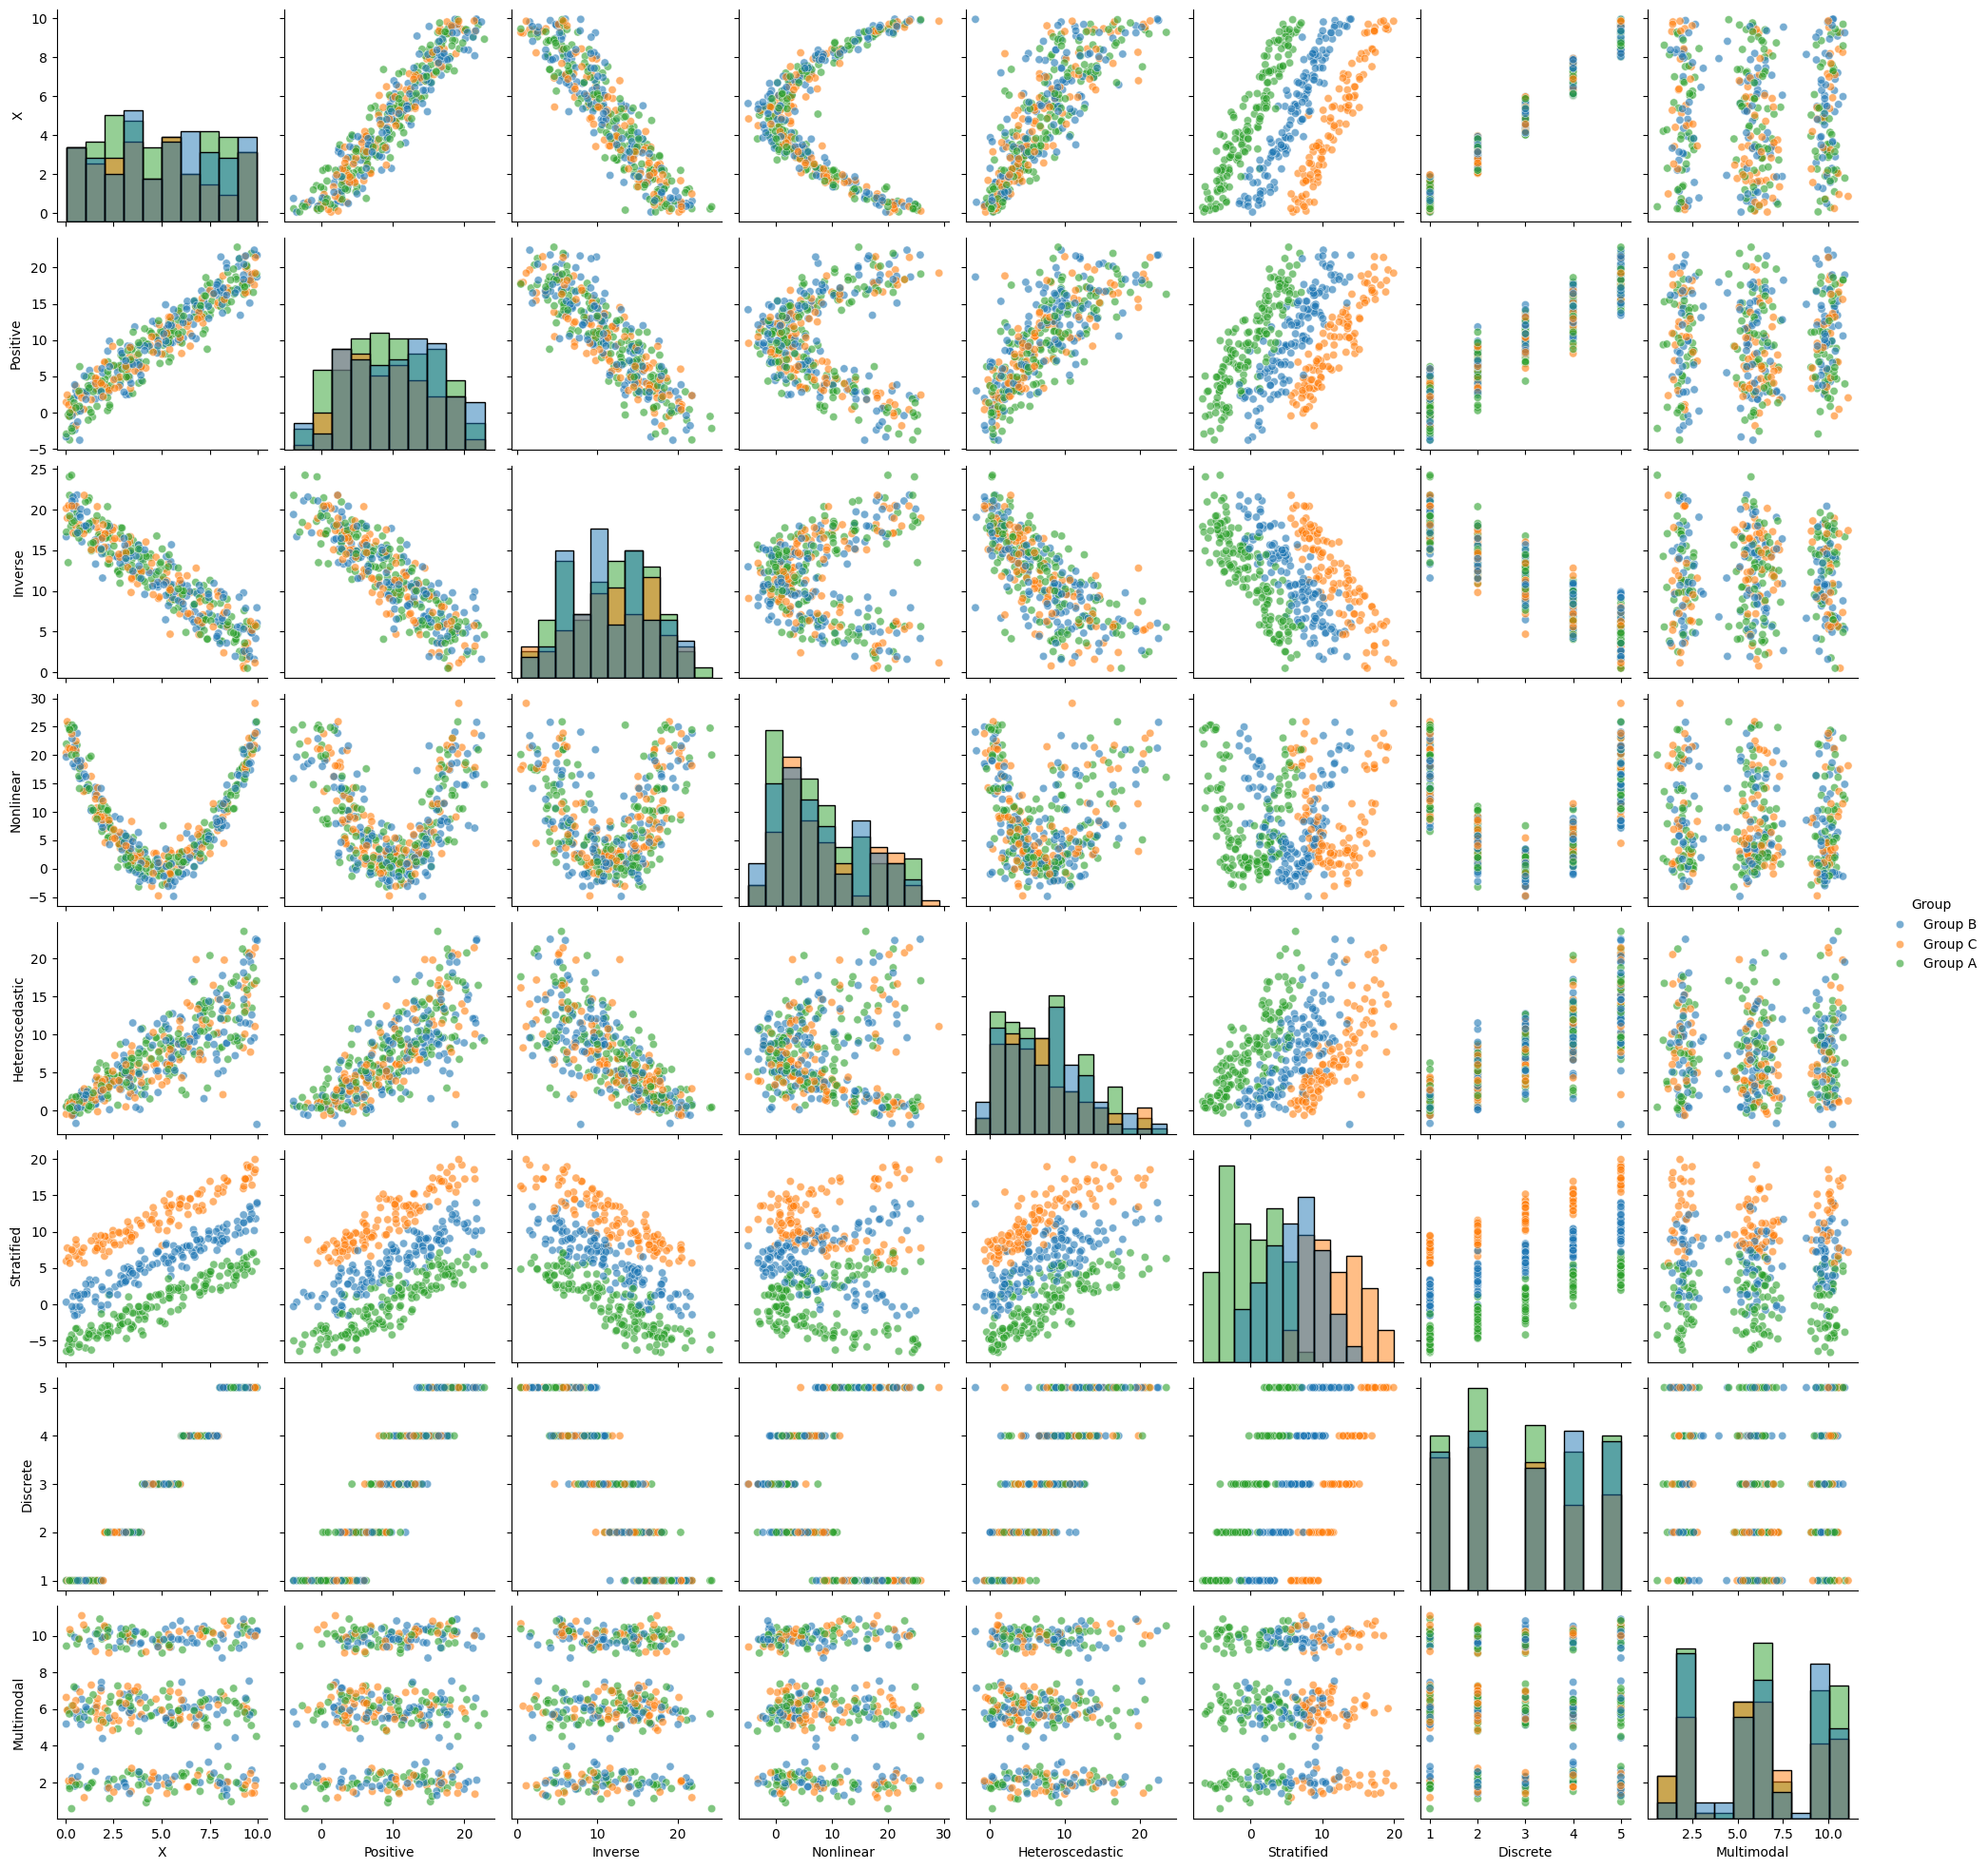

In [3]:
# ============================================================
# Simulated data for demonstrating pairwise relationships
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(541)

n = 400

# ------------------------------------------------------------
# 1. Base continuous variable
# ------------------------------------------------------------
X = np.random.uniform(0, 10, n)

# ------------------------------------------------------------
# 2. Positive linear relationship
# ------------------------------------------------------------
Positive = 2.0 * X + np.random.normal(0, 2, n)

# ------------------------------------------------------------
# 3. Inverse / negative linear relationship
# ------------------------------------------------------------
Inverse = 20 - 1.7 * X + np.random.normal(0, 2, n)

# ------------------------------------------------------------
# 4. Nonlinear relationship
#
# Strong relationship with X, but Pearson correlation may be
# close to zero because the relationship is U-shaped.
# ------------------------------------------------------------
Nonlinear = (X - 5)**2 + np.random.normal(0, 2, n)

# ------------------------------------------------------------
# 5. Heteroscedastic relationship
#
# Error variance increases with X.
# ------------------------------------------------------------
sigma = 0.5 + 0.45 * X

Heteroscedastic = (
    1.5 * X
    + np.random.normal(0, sigma, n)
)

# ------------------------------------------------------------
# 6. Stratification
#
# Three populations/groups having different intercepts.
# ------------------------------------------------------------
Group = np.random.choice(
    ["Group A", "Group B", "Group C"],
    size=n,
    p=[0.35, 0.35, 0.30]
)

group_effect = {
    "Group A": -6,
    "Group B": 0,
    "Group C": 6
}

Stratified = np.array([
    1.2 * x + group_effect[g] + np.random.normal(0, 1.2)
    for x, g in zip(X, Group)
])

# ------------------------------------------------------------
# 7. Discrete / ordinal variable
#
# Convert the continuous X variable into five ordered classes.
# ------------------------------------------------------------
Discrete = pd.cut(
    X,
    bins=[0, 2, 4, 6, 8, 10],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

# ------------------------------------------------------------
# 8. Multimodal variable
#
# Mixture of three Gaussian distributions.
# This creates three distinct modes in the marginal distribution.
# ------------------------------------------------------------

mode = np.random.choice(
    [1, 2, 3],
    size=n,
    p=[0.30, 0.40, 0.30]
)

Multimodal = np.where(
    mode == 1,
    np.random.normal(2, 0.5, n),
    np.where(
        mode == 2,
        np.random.normal(6, 0.7, n),
        np.random.normal(10, 0.5, n)
    )
)

# ------------------------------------------------------------
# Multimodal relationship
#
# Three latent populations with distinct means in both X and Y.
# ------------------------------------------------------------

latent_population = np.random.choice(
    [0, 1, 2],
    size=n,
    p=[0.3, 0.4, 0.3]
)

Multi_X = (
    np.array([2, 6, 10])[latent_population]
    + np.random.normal(0, 0.6, n)
)

Multi_Y = (
    np.array([3, 8, 5])[latent_population]
    + np.random.normal(0, 0.8, n)
)

df["Multi_X"] = Multi_X
df["Multi_Y"] = Multi_Y




df = pd.DataFrame({
    "X": X,
    "Positive": Positive,
    "Inverse": Inverse,
    "Nonlinear": Nonlinear,
    "Heteroscedastic": Heteroscedastic,
    "Stratified": Stratified,
    "Discrete": Discrete,
    "Multimodal": Multimodal,
    "Group": Group
})

df.head()
sns.pairplot(
    df,
    vars=[
        "X",
        "Positive",
        "Inverse",
        "Nonlinear",
        "Heteroscedastic",
        "Stratified",
        "Discrete",
        "Multimodal"
    ],
    hue="Group",
    diag_kind="hist",
    plot_kws={"alpha": 0.6}
)

plt.show()